# Lab Demo: Targeted Adversarial Attacks using FGSM and PGD

**Targeted Fast Gradient Sign Method (FGSM)** — adapted from Goodfellow et al. (2014)  
**Targeted Projected Gradient Descent (PGD)** — an iterative gradient-based attack

## Overview
This notebook demonstrates how a trained MLP classifier on MNIST digits can be **fooled** by adding tiny, human-imperceptible perturbations to input images.

The original FGSM method is usually **untargeted**, meaning it tries to make the model predict any wrong class. In this updated version, the current FGSM attack is **targeted**, meaning it tries to push the model toward a specific target class.

### Targeted FGSM formula:
$$x_{adv} = x - \epsilon \cdot \text{sign}(\nabla_x J(\theta, x, y_{target}))$$

Where:
- $x$ = original image
- $\epsilon$ = perturbation strength
- $y_{target}$ = class we want the model to incorrectly predict
- $\nabla_x J$ = gradient of the loss with respect to the input

The minus sign is important because targeted FGSM **reduces the loss for the target class**, instead of increasing the loss for the true class.

### We will:
1. Load a pre-trained MLP classifier
2. Run targeted FGSM to generate adversarial examples
3. Add targeted PGD as a second attack method
4. Visualise the original, perturbation, and adversarial image
5. Evaluate attack impact across different ε values
6. (Defence) Apply Gaussian smoothing as a simple input pre-processing defence


## 0. Setup — Install / Check packages

In [9]:
# This cell checks that the main Python packages are installed and shows their versions.
# It does not train or attack the model; it only confirms the environment is ready.

import torch
print('torch:', torch.__version__)
import torchvision
print('torchvision:', torchvision.__version__)
import matplotlib
print('matplotlib:', matplotlib.__version__)
import numpy
print('numpy:', numpy.__version__)

torch: 2.11.0+cpu
torchvision: 0.26.0+cpu
matplotlib: 3.10.0
numpy: 2.0.2


In [10]:
# Import the PyTorch tools used to build and run the neural network.
# Import matplotlib and numpy for plotting images, graphs, and arrays.
# The device line chooses GPU if available, otherwise CPU, so the notebook can run in Colab or locally.

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import torchvision
import matplotlib.pyplot as plt
import numpy as np

# Use GPU if available, else CPU
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

Using device: cpu


## 1. Load the Dataset

Upload `train_mnist.pt` and `test_mnist.pt` to your Colab session (or place them in the working directory).

These are pre-processed subsets of MNIST: **6000 training** and **1000 test** examples.

In [11]:
# Load the prepared MNIST training and testing datasets from the .pt files.
# The DataLoaders split the datasets into batches, which makes evaluation and attacks easier to run.
# The classes tuple maps model output numbers 0 to 9 into readable digit names.

print('==> Loading data..')
train_data = torch.load('train_mnist.pt', weights_only=False)
test_data  = torch.load('test_mnist.pt',  weights_only=False)
print(f'Train samples: {len(train_data)}')
print(f'Test  samples: {len(test_data)}')

train_loader = torch.utils.data.DataLoader(train_data, batch_size=128, shuffle=True,  num_workers=2)
test_loader  = torch.utils.data.DataLoader(test_data,  batch_size=128, shuffle=False, num_workers=2)

classes = ('zero', 'one', 'two', 'three', 'four', 'five', 'six', 'seven', 'eight', 'nine')

==> Loading data..
Train samples: 6000
Test  samples: 1000


## 2. Define the MLP Classifier (Victim Model)

In [12]:
# Define the victim model that the FGSM attack will target.
# This is a simple fully connected neural network for classifying 28x28 MNIST digit images.
# The model outputs 10 raw scores, one for each digit class from 0 to 9.

class Classifier(nn.Module):
    """3-layer MLP for 28x28 grayscale digit classification."""
    def __init__(self):
        super(Classifier, self).__init__()
        self.fc1 = nn.Linear(28 * 28, 512)
        self.fc2 = nn.Linear(512, 128)
        self.fc3 = nn.Linear(128, 10)

    def forward(self, x):
        x = x.view(-1, 28 * 28)   # flatten
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = self.fc3(x)            # raw logits (no softmax — CrossEntropyLoss handles it)
        return x

print('Classifier architecture defined.')

Classifier architecture defined.


## 3. Load the Pre-trained Model

Upload `MLP_MNIST.pth` to your Colab session.

If you prefer to train from scratch, run the optional training cell below first.

In [13]:
# Load the already-trained victim model from MLP_MNIST.pth.
# This avoids needing to retrain the model
# net.eval() puts the model into evaluation mode, which is used for testing and attacks.

# ── Option A: Load the saved model (recommended for demo) ──────────────────
net = Classifier().to(device)
checkpoint = torch.load('MLP_MNIST.pth', map_location=device, weights_only=False)
net.load_state_dict(checkpoint['model_state_dict'])
net.eval()
print('Pre-trained model loaded successfully.')
print(net)

Pre-trained model loaded successfully.
Classifier(
  (fc1): Linear(in_features=784, out_features=512, bias=True)
  (fc2): Linear(in_features=512, out_features=128, bias=True)
  (fc3): Linear(in_features=128, out_features=10, bias=True)
)


In [14]:
# Optional training code only.
# Keep this cell skipped if using the provided saved model.
# It is included to show how the model could be trained from scratch if the .pth file was not available.

# ── Option B: Train from scratch (skip if using Option A) ──────────────────
# Uncomment and run this cell if you do NOT have MLP_MNIST.pth

# net = Classifier().to(device)
# criterion = nn.CrossEntropyLoss()
# optimizer = optim.SGD(net.parameters(), lr=0.001, momentum=0.9, weight_decay=5e-4)
#
# for epoch in range(10):
#     net.train()
#     for inputs, targets in train_loader:
#         inputs, targets = inputs.to(device), targets.to(device)
#         optimizer.zero_grad()
#         loss = criterion(net(inputs), targets)
#         loss.backward()
#         optimizer.step()
#
#     net.eval()
#     correct = total = 0
#     with torch.no_grad():
#         for inputs, targets in test_loader:
#             inputs, targets = inputs.to(device), targets.to(device)
#             _, predicted = net(inputs).max(1)
#             total += targets.size(0)
#             correct += predicted.eq(targets).sum().item()
#     print(f'Epoch {epoch}: Accuracy = {100.*correct/total:.1f}%')
#
# net.eval()
# print('Training complete.')

## 4. Evaluate Baseline Accuracy (No Attack)

In [15]:
# Define the loss function and a helper function to measure normal model accuracy.
# This gives the clean baseline result before any adversarial attack is applied.
# The baseline accuracy is important because later results are compared against it.

criterion = nn.CrossEntropyLoss()

def evaluate(model, loader):
    """Return accuracy (%) on the given DataLoader."""
    model.eval()
    correct = total = 0
    with torch.no_grad():
        for inputs, targets in loader:
            inputs, targets = inputs.to(device), targets.to(device)
            _, predicted = model(inputs).max(1)
            total   += targets.size(0)
            correct += predicted.eq(targets).sum().item()
    return 100. * correct / total

baseline_acc = evaluate(net, test_loader)
print(f'Baseline accuracy (no attack): {baseline_acc:.2f}%')

Baseline accuracy (no attack): 78.10%


## 5. Targeted FGSM Attack Implementation

Targeted FGSM tries to force the model to predict a specific wrong class, rather than just any incorrect class.

In this notebook, the default target class is the next digit:  
`0 → 1`, `1 → 2`, `2 → 3`, ..., `9 → 0`.

The attack computes the gradient of the loss with respect to the **target label**, then moves the image in the direction that makes the target class more likely.

$$x_{adv} = x - \epsilon \cdot \text{sign}(\nabla_x J(\theta, x, y_{target}))$$


In [16]:
# Define the targeted FGSM attack.
# Standard FGSM is usually untargeted, meaning it increases the loss for the true label.
# This version is targeted, meaning it reduces the loss for a chosen target label.
# The model weights are not changed here; only the input image is modified.


def choose_target_labels(labels):
    """
    Choose a target class for each true label.

    The default strategy is simple and easy to explain:
    each digit is attacked toward the next digit class.
    Example: 0 becomes target 1, 1 becomes target 2, ..., 9 becomes target 0.
    """
    labels = labels.to(device)
    return (labels + 1) % 10


def fgsm_attack(model, x, true_labels, epsilon, target_labels=None):
    """
    Perform a single-step targeted FGSM attack.

    Args:
        model        : victim classifier
        x            : original input images (batch)
        true_labels  : real class labels
        epsilon      : perturbation magnitude
        target_labels: class labels the attacker wants the model to predict

    Returns:
        adv_x        : adversarial images (same shape as x)
        perturbation : signed gradient scaled by epsilon
        target_labels: target labels used by the attack
    """
    x = x.clone().detach().to(device)
    true_labels = true_labels.to(device)

    # If no target label is provided, use the next digit as the target class.
    if target_labels is None:
        target_labels = choose_target_labels(true_labels)
    else:
        target_labels = target_labels.to(device)

    # Enable gradients for the input image because the attack changes the image, not the model.
    x.requires_grad = True

    # Forward pass through the victim model.
    outputs = model(x)
    model.zero_grad()

    # For a targeted attack, the loss is calculated against the target labels.
    # The attack will then move the image in the direction that makes this target more likely.
    loss = criterion(outputs, target_labels)

    # Backward pass computes d(loss)/d(input image).
    loss.backward()

    # Take the sign of the gradient to get the pixel direction for the attack.
    sign_grad = x.grad.data.sign()

    # Targeted FGSM subtracts the gradient direction.
    # This reduces the loss for the target class, making the target prediction more likely.
    perturbation = -epsilon * sign_grad

    # Add the perturbation, then clamp pixels so they stay in the valid image range [0, 1].
    adv_x = torch.clamp(x + perturbation, 0, 1).detach()

    return adv_x, perturbation.detach(), target_labels.detach()

print('Targeted FGSM function defined.')


Targeted FGSM function defined.


## 5.1 Second Attack Method: Targeted PGD

Projected Gradient Descent (PGD) is a stronger iterative version of FGSM.  
Instead of taking one large step, it takes several smaller targeted steps and keeps the total perturbation inside the allowed ε range.

This makes PGD useful for comparison because it usually creates stronger adversarial examples than single-step FGSM.


In [17]:
# Define targeted PGD as the second attack method.
# PGD repeats small targeted FGSM-style steps several times.
# After every step, the image is projected back into the allowed epsilon range.


def targeted_pgd_attack(model, x, true_labels, epsilon, alpha=1/255, num_steps=10, target_labels=None):
    """
    Perform a targeted Projected Gradient Descent attack.

    Args:
        model        : victim classifier
        x            : original input images (batch)
        true_labels  : real class labels
        epsilon      : maximum total perturbation allowed
        alpha        : step size for each PGD update
        num_steps    : number of attack steps
        target_labels: class labels the attacker wants the model to predict

    Returns:
        adv_x        : adversarial images
        perturbation : final perturbation added to the original image
        target_labels: target labels used by the attack
    """
    original_x = x.clone().detach().to(device)
    true_labels = true_labels.to(device)

    # Use the same target-label strategy as targeted FGSM unless specific targets are supplied.
    if target_labels is None:
        target_labels = choose_target_labels(true_labels)
    else:
        target_labels = target_labels.to(device)

    # Start from the clean image. A random start could also be used, but this is simpler for demonstration.
    adv_x = original_x.clone().detach()

    for step in range(num_steps):
        adv_x.requires_grad = True

        # Calculate the model output and target-class loss for the current adversarial image.
        outputs = model(adv_x)
        model.zero_grad()
        loss = criterion(outputs, target_labels)

        # Compute the gradient of the target loss with respect to the image.
        loss.backward()

        # Take a small targeted step by subtracting the sign of the gradient.
        adv_x = adv_x.detach() - alpha * adv_x.grad.data.sign()

        # Keep the total change within the allowed epsilon ball around the original image.
        delta = torch.clamp(adv_x - original_x, min=-epsilon, max=epsilon)
        adv_x = torch.clamp(original_x + delta, 0, 1).detach()

    perturbation = adv_x - original_x
    return adv_x.detach(), perturbation.detach(), target_labels.detach()

print('Targeted PGD function defined.')


Targeted PGD function defined.


## 6. Visualise Targeted Adversarial Examples

For each selected digit, ε is gradually increased until the targeted FGSM attack succeeds.  
Success means the classifier predicts the chosen target class, not just any wrong class.

The display shows: **Original | Perturbation (amplified) | Targeted adversarial image**.


In [18]:
# Prepare a small batch of test images for visual demonstration.
# The code finds one correctly classified image from each digit class.
# Using correctly classified images makes the attack result easier to explain because the model starts off right.

# Load 100 test images
single_loader = torch.utils.data.DataLoader(test_data, batch_size=100, shuffle=False)
dataiter = iter(single_loader)
org_images, org_labels = next(dataiter)

# Run baseline predictions
with torch.no_grad():
    outputs   = net(org_images.to(device))
    _, predicted = torch.max(outputs, 1)

# Select one correctly-classified example from each class
selected_indices = []
for cls in range(10):
    for idx in range(100):
        if org_labels[idx].item() == cls and predicted[idx].item() == cls:
            selected_indices.append(idx)
            break

print(f'Selected {len(selected_indices)} correctly classified examples (one per class).')

Selected 9 correctly classified examples (one per class).


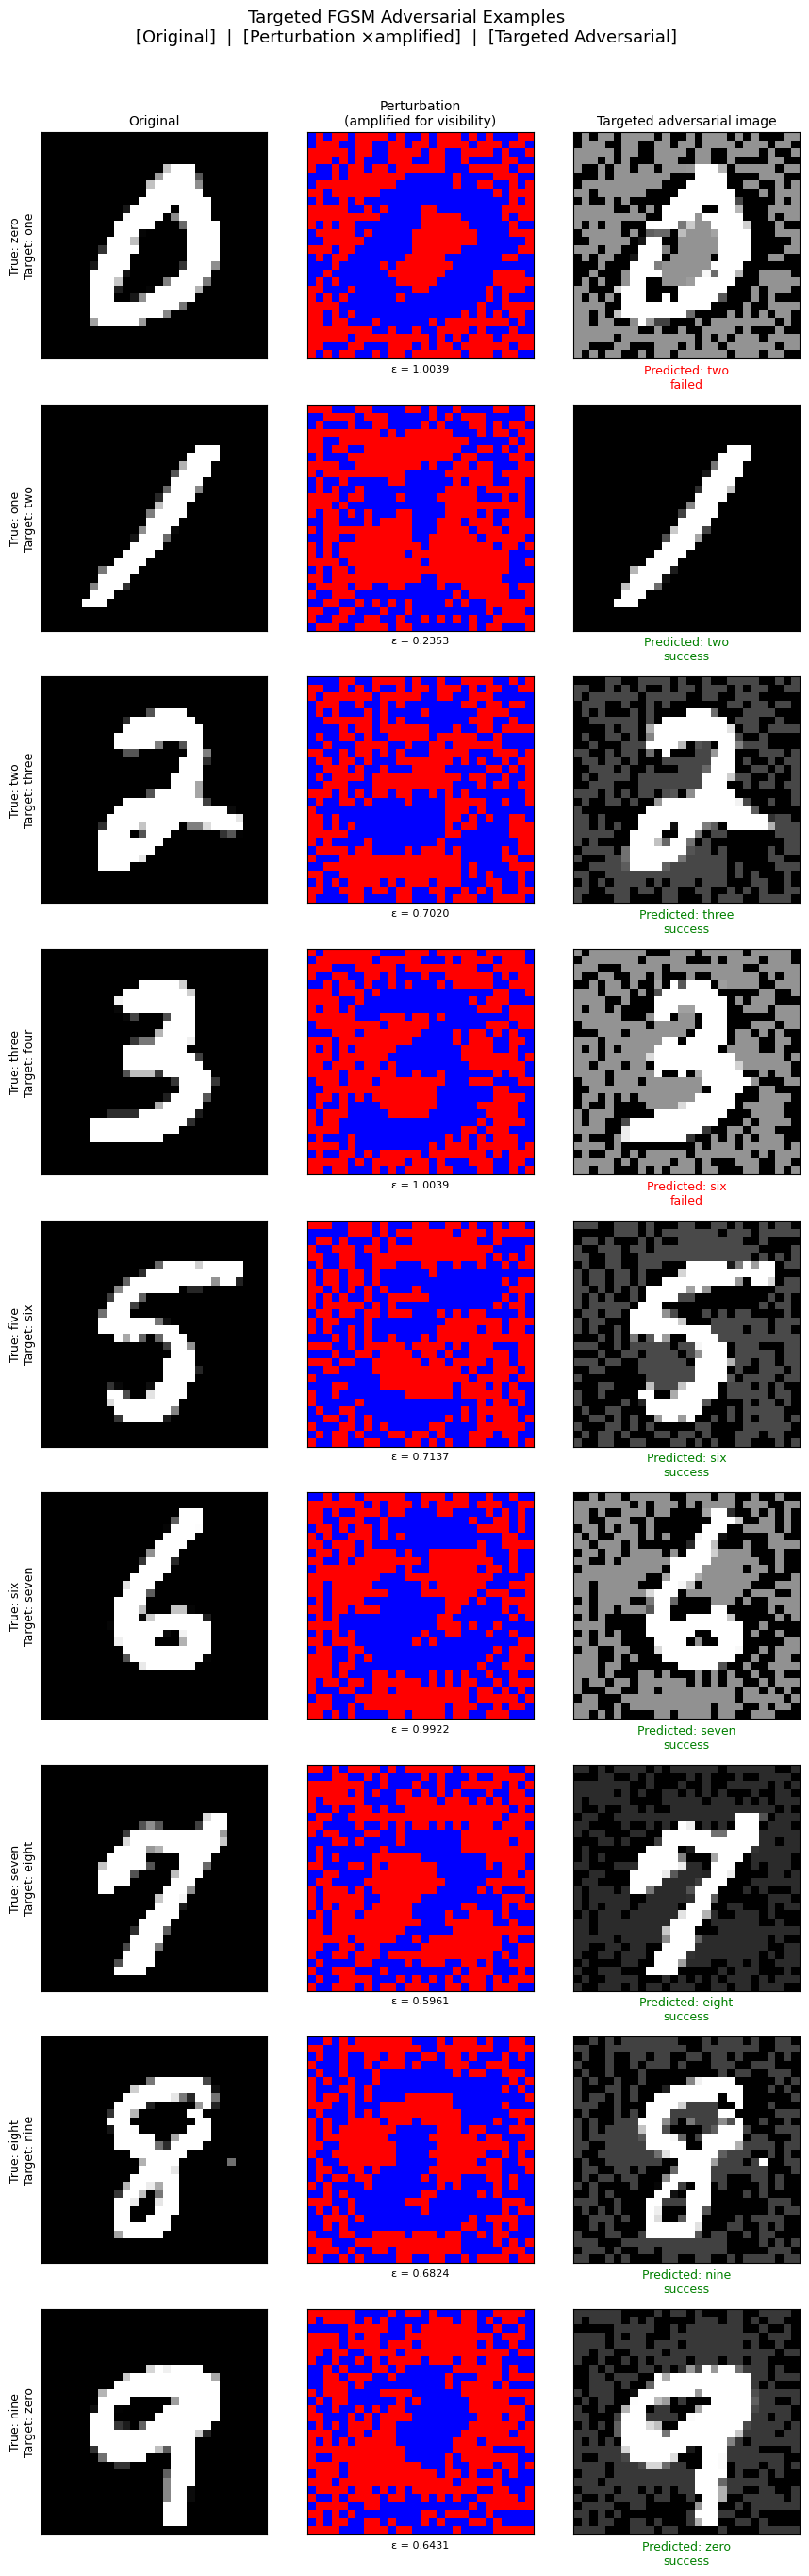

Figure saved as targeted_fgsm_examples.png


In [19]:
# Create and display targeted adversarial examples for the selected digits.
# For each digit, epsilon is slowly increased until the model predicts the target class.
# The figure shows the original image, the perturbation, and the final targeted adversarial image.

base_eps = 1 / 255  # ≈ 0.004 — one grey level on an 8-bit image

fig, axes = plt.subplots(len(selected_indices), 3,
                          figsize=(9, 3 * len(selected_indices)))
fig.suptitle('Targeted FGSM Adversarial Examples\n'
             '[Original]  |  [Perturbation ×amplified]  |  [Targeted Adversarial]',
             fontsize=13, y=1.01)

col_titles = ['Original', 'Perturbation\n(amplified for visibility)', 'Targeted adversarial image']
for ax, title in zip(axes[0], col_titles):
    ax.set_title(title, fontsize=10)

attack_results = []   # store for later analysis

for row, idx in enumerate(selected_indices):
    image = org_images[idx:idx+1].clone()
    true_label = org_labels[idx:idx+1]
    target_label = choose_target_labels(true_label)

    true_cls = classes[true_label.item()]
    target_cls = classes[target_label.item()]

    # Increase epsilon until the targeted attack succeeds.
    # A successful targeted attack means prediction == target label.
    eps = base_eps
    success = False
    while not success and eps <= 1.0:
        adv_img, pert, used_target = fgsm_attack(net, image, true_label, eps, target_label)
        with torch.no_grad():
            out = net(adv_img.to(device))
            _, pred = torch.max(out, 1)

        if pred.item() == used_target.item():
            success = True
        else:
            eps += base_eps

    adv_cls = classes[pred.item()]
    attack_results.append({
        'true': true_cls,
        'target': target_cls,
        'prediction': adv_cls,
        'eps': eps,
        'success': success
    })

    # ── Plot ──────────────────────────────────────────────────────────────
    orig_np = image[0, 0].numpy()
    pert_np = pert[0, 0].cpu().numpy()
    adv_np  = adv_img[0, 0].cpu().numpy()

    axes[row, 0].imshow(orig_np, cmap='gray', vmin=0, vmax=1)
    axes[row, 0].set_ylabel(f'True: {true_cls}\nTarget: {target_cls}', fontsize=9)

    # Amplify perturbation for visibility because the actual perturbation is tiny.
    pert_vis = (pert_np - pert_np.min()) / (pert_np.max() - pert_np.min() + 1e-8)
    axes[row, 1].imshow(pert_vis, cmap='bwr', vmin=0, vmax=1)
    axes[row, 1].set_xlabel(f'ε = {eps:.4f}', fontsize=8)

    result_text = 'success' if success else 'failed'
    axes[row, 2].imshow(np.clip(adv_np, 0, 1), cmap='gray', vmin=0, vmax=1)
    axes[row, 2].set_xlabel(f'Predicted: {adv_cls}\n{result_text}', fontsize=9,
                             color='green' if success else 'red')

    for ax in axes[row]:
        ax.set_xticks([])
        ax.set_yticks([])

plt.tight_layout()
plt.savefig('targeted_fgsm_examples.png', dpi=120, bbox_inches='tight')
plt.show()
print('Figure saved as targeted_fgsm_examples.png')


## 7. Accuracy and Target Success vs. ε

We sweep ε from 0 to 0.3 and measure two values:

- **Clean-label accuracy**: how often the model still predicts the true label after the attack.
- **Target success rate**: how often the model predicts the attacker’s chosen target label.


In [20]:
# Evaluate how the targeted FGSM attack behaves across different epsilon values.
# A larger epsilon means a stronger perturbation, so clean-label accuracy should fall.
# For a targeted attack, target success rate is also important because it shows whether the chosen target was reached.


def evaluate_under_fgsm(model, loader, epsilon):
    """
    Attack every batch in loader with targeted FGSM(epsilon).

    Returns:
        clean_accuracy      : percentage still classified as the true label
        target_success_rate : percentage classified as the chosen target label
    """
    model.eval()
    correct = 0
    target_hits = 0
    total = 0

    for inputs, true_labels in loader:
        inputs = inputs.to(device)
        true_labels = true_labels.to(device)
        target_labels = choose_target_labels(true_labels)

        adv_inputs, _, target_labels = fgsm_attack(model, inputs, true_labels, epsilon, target_labels)

        with torch.no_grad():
            _, predicted = model(adv_inputs).max(1)

        total += true_labels.size(0)
        correct += predicted.eq(true_labels).sum().item()
        target_hits += predicted.eq(target_labels).sum().item()

    clean_accuracy = 100. * correct / total
    target_success_rate = 100. * target_hits / total
    return clean_accuracy, target_success_rate


epsilons = [0, 1/255, 2/255, 4/255, 8/255, 16/255, 0.1, 0.15, 0.2, 0.25, 0.3]
accuracies = []
target_success_rates = []

print('Sweeping epsilon values for targeted FGSM...')
print(f'{"ε":>8}  {"Clean Acc":>10}  {"Target Success":>15}')
print('-' * 40)
for eps in epsilons:
    acc, target_success = evaluate_under_fgsm(net, test_loader, eps)
    accuracies.append(acc)
    target_success_rates.append(target_success)
    print(f'{eps:>8.4f}  {acc:>9.2f}%  {target_success:>14.2f}%')


Sweeping epsilon values for targeted FGSM...
       ε   Clean Acc   Target Success
----------------------------------------
  0.0000      74.30%            1.50%
  0.0039      74.20%            1.60%
  0.0078      74.20%            1.60%
  0.0157      74.20%            1.60%
  0.0314      74.20%            1.60%
  0.0627      74.10%            1.80%
  0.1000      73.70%            1.90%
  0.1500      73.60%            2.40%
  0.2000      73.60%            2.50%
  0.2500      73.00%            2.80%
  0.3000      72.50%            3.30%


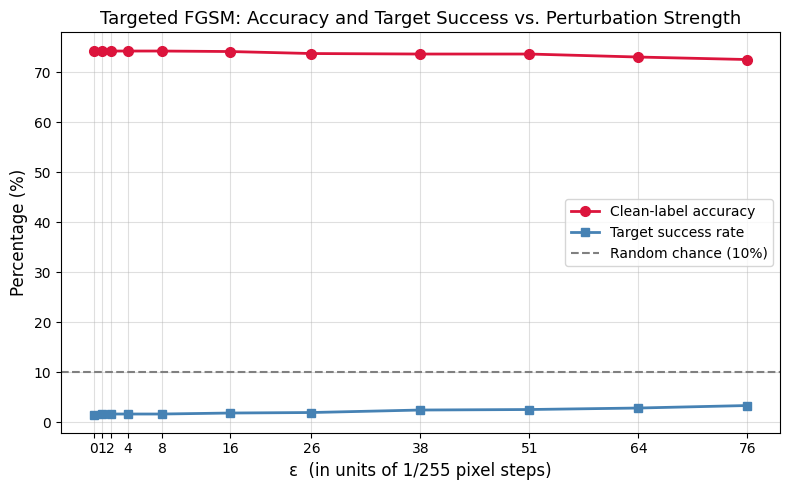

Plot saved as targeted_fgsm_accuracy_curve.png


In [21]:
# Plot how targeted FGSM changes clean-label accuracy and target success rate.
# Clean-label accuracy should decrease as epsilon grows.
# Target success rate should generally increase because the attack has more room to push images toward the target class.

plt.figure(figsize=(8, 5))
plt.plot([e * 255 for e in epsilons], accuracies, 'o-', color='crimson', linewidth=2, markersize=7,
         label='Clean-label accuracy')
plt.plot([e * 255 for e in epsilons], target_success_rates, 's-', color='steelblue', linewidth=2, markersize=6,
         label='Target success rate')
plt.axhline(y=10, color='gray', linestyle='--', label='Random chance (10%)')
plt.xlabel('ε  (in units of 1/255 pixel steps)', fontsize=12)
plt.ylabel('Percentage (%)', fontsize=12)
plt.title('Targeted FGSM: Accuracy and Target Success vs. Perturbation Strength', fontsize=13)
plt.xticks([e * 255 for e in epsilons], [f'{e*255:.0f}' for e in epsilons])
plt.legend(fontsize=10)
plt.grid(True, alpha=0.4)
plt.tight_layout()
plt.savefig('targeted_fgsm_accuracy_curve.png', dpi=120)
plt.show()
print('Plot saved as targeted_fgsm_accuracy_curve.png')


## 7.1 Compare Targeted FGSM and Targeted PGD

This section compares the current targeted FGSM attack with the new targeted PGD attack.

FGSM takes one step, while PGD takes multiple smaller steps, so PGD is expected to achieve a higher target success rate at the same ε value.


In [22]:
# Compare targeted FGSM against targeted PGD.
# The comparison focuses on clean-label accuracy and target success rate for both attacks.


def evaluate_under_targeted_pgd(model, loader, epsilon, alpha=1/255, num_steps=10):
    """
    Attack every batch in loader with targeted PGD.

    Returns:
        clean_accuracy      : percentage still classified as the true label
        target_success_rate : percentage classified as the chosen target label
    """
    model.eval()
    correct = 0
    target_hits = 0
    total = 0

    for inputs, true_labels in loader:
        inputs = inputs.to(device)
        true_labels = true_labels.to(device)
        target_labels = choose_target_labels(true_labels)

        adv_inputs, _, target_labels = targeted_pgd_attack(
            model,
            inputs,
            true_labels,
            epsilon,
            alpha=alpha,
            num_steps=num_steps,
            target_labels=target_labels
        )

        with torch.no_grad():
            _, predicted = model(adv_inputs).max(1)

        total += true_labels.size(0)
        correct += predicted.eq(true_labels).sum().item()
        target_hits += predicted.eq(target_labels).sum().item()

    clean_accuracy = 100. * correct / total
    target_success_rate = 100. * target_hits / total
    return clean_accuracy, target_success_rate


comparison_epsilons = [0, 4/255, 8/255, 16/255, 0.1]
fgsm_acc_compare = []
fgsm_tsr_compare = []
pgd_acc_compare = []
pgd_tsr_compare = []

print('Comparing targeted FGSM and targeted PGD')
print(f'{"ε":>8}  {"FGSM Acc":>9}  {"FGSM Target":>12}  {"PGD Acc":>8}  {"PGD Target":>11}')
print('-' * 62)

for eps in comparison_epsilons:
    fgsm_acc, fgsm_tsr = evaluate_under_fgsm(net, test_loader, eps)
    pgd_acc, pgd_tsr = evaluate_under_targeted_pgd(net, test_loader, eps, alpha=1/255, num_steps=10)

    fgsm_acc_compare.append(fgsm_acc)
    fgsm_tsr_compare.append(fgsm_tsr)
    pgd_acc_compare.append(pgd_acc)
    pgd_tsr_compare.append(pgd_tsr)

    print(f'{eps:>8.4f}  {fgsm_acc:>8.2f}%  {fgsm_tsr:>11.2f}%  {pgd_acc:>7.2f}%  {pgd_tsr:>10.2f}%')


Comparing targeted FGSM and targeted PGD
       ε   FGSM Acc   FGSM Target   PGD Acc   PGD Target
--------------------------------------------------------------
  0.0000     74.30%         1.50%    74.30%        1.50%
  0.0157     74.20%         1.60%    74.20%        1.60%
  0.0314     74.20%         1.60%    74.30%        1.60%
  0.0627     74.10%         1.80%    74.30%        1.60%
  0.1000     73.70%         1.90%    74.30%        1.60%


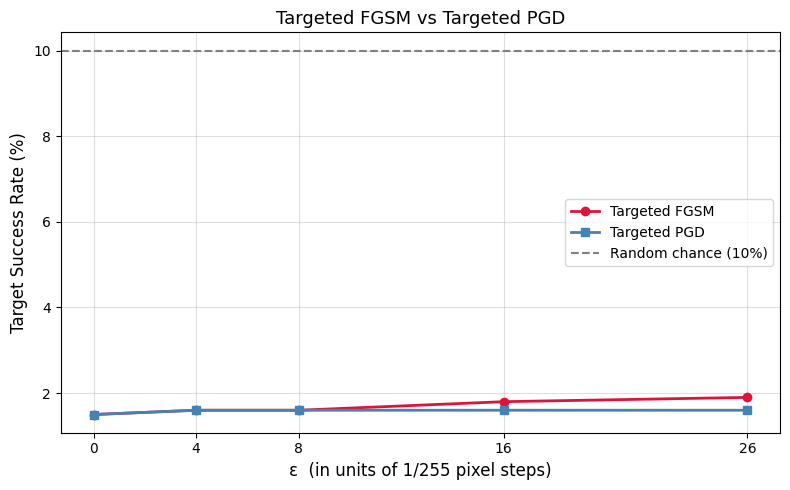

Plot saved as targeted_attack_comparison.png


In [23]:
# Plot the target success rate for targeted FGSM and targeted PGD.
# This graph shows which attack is better at forcing the model into the chosen target class.

plt.figure(figsize=(8, 5))
x_values = [e * 255 for e in comparison_epsilons]

plt.plot(x_values, fgsm_tsr_compare, 'o-', color='crimson', linewidth=2, label='Targeted FGSM')
plt.plot(x_values, pgd_tsr_compare, 's-', color='steelblue', linewidth=2, label='Targeted PGD')
plt.axhline(y=10, color='gray', linestyle='--', label='Random chance (10%)')

plt.xlabel('ε  (in units of 1/255 pixel steps)', fontsize=12)
plt.ylabel('Target Success Rate (%)', fontsize=12)
plt.title('Targeted FGSM vs Targeted PGD', fontsize=13)
plt.xticks(x_values, [f'{e*255:.0f}' for e in comparison_epsilons])
plt.legend(fontsize=10)
plt.grid(True, alpha=0.4)
plt.tight_layout()
plt.savefig('targeted_attack_comparison.png', dpi=120)
plt.show()
print('Plot saved as targeted_attack_comparison.png')


## 8. Defence: Gaussian Smoothing (Input Pre-processing)

A simple defence: apply a Gaussian blur to the adversarial image before feeding it into the classifier.  
The blur removes some high-frequency perturbations while preserving the coarse digit structure.

This is a **pre-processing defence**, so the model itself is not retrained.


In [24]:
# Define a simple Gaussian smoothing defence.
# The idea is to blur the adversarial image to reduce high-frequency attack noise.
# This is an input pre-processing defence, so the model itself is not retrained.

from scipy.ndimage import gaussian_filter


def gaussian_defence(images_tensor, sigma=1.0):
    """
    Apply Gaussian blur to a batch of images (N, C, H, W) as a pre-processing defence.
    Returns a new tensor of the same shape.
    """
    np_imgs = images_tensor.cpu().numpy()
    smoothed = np.stack([
        gaussian_filter(img, sigma=sigma)
        for img in np_imgs
    ])
    return torch.tensor(smoothed, dtype=torch.float32)


def evaluate_with_defence(model, loader, epsilon, sigma):
    """
    Targeted FGSM attack + Gaussian smoothing defence.

    Returns:
        defended_accuracy       : percentage still classified as the true label after defence
        defended_target_success : percentage still classified as the target label after defence
    """
    model.eval()
    correct = 0
    target_hits = 0
    total = 0

    for inputs, true_labels in loader:
        inputs = inputs.to(device)
        true_labels = true_labels.to(device)
        target_labels = choose_target_labels(true_labels)

        # 1. Attack with targeted FGSM.
        adv_inputs, _, target_labels = fgsm_attack(model, inputs, true_labels, epsilon, target_labels)

        # 2. Defend by blurring the adversarial images before classification.
        defended = gaussian_defence(adv_inputs, sigma=sigma).to(device)

        with torch.no_grad():
            _, predicted = model(defended).max(1)

        total += true_labels.size(0)
        correct += predicted.eq(true_labels).sum().item()
        target_hits += predicted.eq(target_labels).sum().item()

    defended_accuracy = 100. * correct / total
    defended_target_success = 100. * target_hits / total
    return defended_accuracy, defended_target_success

print('Defence function defined.')


Defence function defined.


In [25]:
# Compare the attacked model with no defence against the attacked model with Gaussian smoothing.
# This table shows whether the defence recovers clean-label accuracy and reduces target success.
# sigma controls blur strength; too much blur can remove useful digit details as well as noise.

# Compare: no defence vs. Gaussian defence across epsilon values.
test_epsilons = [0, 4/255, 8/255, 16/255, 0.1, 0.2, 0.3]
acc_no_defence = []
acc_defended = []
tsr_no_defence = []
tsr_defended = []

sigma = 1.0  # blur strength — try 0.5 or 1.5 to see the tradeoff

print(f'Comparing no-defence vs. Gaussian blur (σ={sigma})')
print(f'{"ε":>8}  {"No Def Acc":>11}  {"No Def Target":>14}  {"Def Acc":>9}  {"Def Target":>11}')
print('-' * 65)
for eps in test_epsilons:
    acc_no, tsr_no = evaluate_under_fgsm(net, test_loader, eps)
    acc_def, tsr_def = evaluate_with_defence(net, test_loader, eps, sigma)

    acc_no_defence.append(acc_no)
    acc_defended.append(acc_def)
    tsr_no_defence.append(tsr_no)
    tsr_defended.append(tsr_def)

    print(f'{eps:>8.4f}  {acc_no:>10.2f}%  {tsr_no:>13.2f}%  {acc_def:>8.2f}%  {tsr_def:>10.2f}%')


Comparing no-defence vs. Gaussian blur (σ=1.0)
       ε   No Def Acc   No Def Target    Def Acc   Def Target
-----------------------------------------------------------------
  0.0000       74.30%           1.50%     71.10%        1.60%
  0.0157       74.20%           1.60%     71.20%        1.60%
  0.0314       74.20%           1.60%     71.10%        1.60%
  0.0627       74.10%           1.80%     70.80%        1.60%
  0.1000       73.70%           1.90%     70.50%        1.80%
  0.2000       73.60%           2.50%     69.10%        2.10%
  0.3000       72.50%           3.30%     68.30%        2.40%


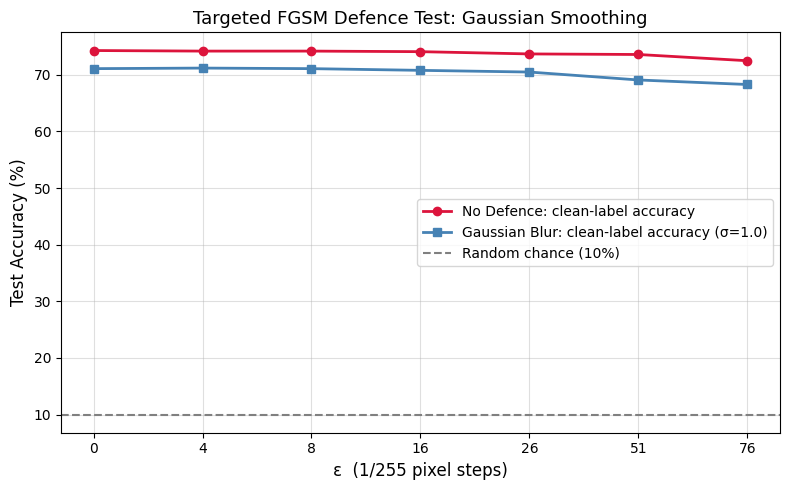

Plot saved as targeted_fgsm_defence_comparison.png


In [26]:
# Plot the no-defence and defended clean-label accuracy results on the same graph.
# This makes it easier to compare whether Gaussian smoothing helps at each epsilon value.
# The plot is also saved as an image file for use in the report or presentation.

plt.figure(figsize=(8, 5))
x_labels = [f'{e*255:.0f}' for e in test_epsilons]
x_pos = range(len(test_epsilons))

plt.plot(x_pos, acc_no_defence, 'o-', color='crimson',  linewidth=2, label='No Defence: clean-label accuracy')
plt.plot(x_pos, acc_defended,   's-', color='steelblue', linewidth=2, label=f'Gaussian Blur: clean-label accuracy (σ={sigma})')
plt.axhline(y=10, color='gray', linestyle='--', label='Random chance (10%)')

plt.xticks(x_pos, x_labels)
plt.xlabel('ε  (1/255 pixel steps)', fontsize=12)
plt.ylabel('Test Accuracy (%)', fontsize=12)
plt.title('Targeted FGSM Defence Test: Gaussian Smoothing', fontsize=13)
plt.legend(fontsize=10)
plt.grid(True, alpha=0.4)
plt.tight_layout()
plt.savefig('targeted_fgsm_defence_comparison.png', dpi=120)
plt.show()
print('Plot saved as targeted_fgsm_defence_comparison.png')


## 9. Visualise the Defence Effect (Side-by-side)

Show one example at a fixed ε: original → targeted adversarial → defended.


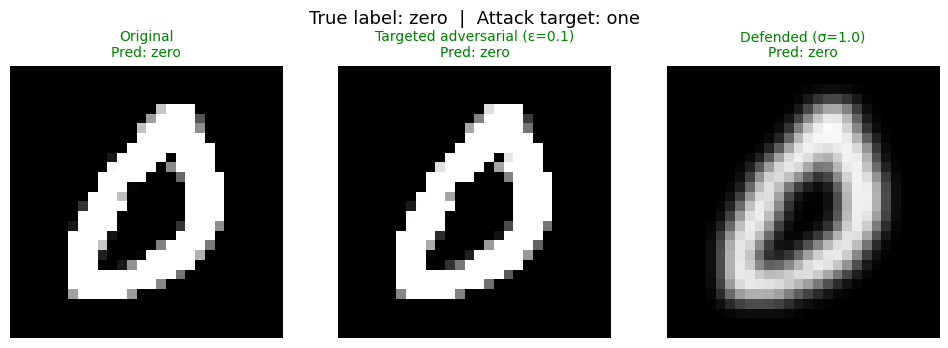

Figure saved as targeted_fgsm_defence_example.png


In [27]:
# Visualise one complete example of the defence process.
# The three images show: original input, targeted adversarial input, and smoothed/defended input.
# The predictions under each image show whether the attack and defence changed the model's decision.

demo_eps = 0.1
demo_sigma = 1.0

# Pick the first correctly-classified test image.
image = org_images[selected_indices[0]:selected_indices[0]+1].clone()
true_label = org_labels[selected_indices[0]:selected_indices[0]+1]
target_label = choose_target_labels(true_label)

# Attack using targeted FGSM.
adv_img, pert, target_label = fgsm_attack(net, image, true_label, demo_eps, target_label)

# Defend using Gaussian smoothing.
defended_img = gaussian_defence(adv_img, sigma=demo_sigma)

# Predictions for the original, adversarial, and defended images.
with torch.no_grad():
    pred_orig = classes[net(image.to(device)).argmax(1).item()]
    pred_adv = classes[net(adv_img.to(device)).argmax(1).item()]
    pred_def = classes[net(defended_img.to(device)).argmax(1).item()]

true_cls = classes[true_label.item()]
target_cls = classes[target_label.item()]

imgs = [
    (image[0, 0].numpy(), f'Original\nPred: {pred_orig}'),
    (adv_img[0, 0].cpu().numpy(), f'Targeted adversarial (ε={demo_eps})\nPred: {pred_adv}'),
    (defended_img[0, 0].cpu().numpy(), f'Defended (σ={demo_sigma})\nPred: {pred_def}'),
]

fig, axes = plt.subplots(1, 3, figsize=(10, 3.5))
fig.suptitle(f'True label: {true_cls}  |  Attack target: {target_cls}', fontsize=13)
for ax, (img, title) in zip(axes, imgs):
    predicted_class = title.split('Pred: ')[-1]
    ax.imshow(np.clip(img, 0, 1), cmap='gray', vmin=0, vmax=1)
    ax.set_title(title, fontsize=10,
                 color='green' if predicted_class == true_cls else ('orange' if predicted_class == target_cls else 'red'))
    ax.axis('off')

plt.tight_layout()
plt.savefig('targeted_fgsm_defence_example.png', dpi=120)
plt.show()
print('Figure saved as targeted_fgsm_defence_example.png')


## 10. Summary

| Scenario | What it measures |
|---|---|
| Clean baseline | Normal model accuracy before attack |
| Targeted FGSM | One-step attack that pushes each image toward a chosen target class |
| Targeted PGD | Multi-step targeted attack that usually gives stronger results than FGSM |
| Targeted FGSM + Gaussian blur | Simple pre-processing defence that tries to reduce attack noise |

### Key Takeaways

**Attack side:**
- The original FGSM method has been changed into a **targeted** attack.
- A targeted attack is stricter than an untargeted attack because success requires the model to predict the attacker's chosen target class.
- The default target rule in this notebook is simple: each digit is targeted toward the next digit class.
- Targeted PGD has been added as a second method and is expected to be stronger because it uses repeated small updates.

**Defence side:**
- Gaussian smoothing removes some high-frequency noise introduced by the attack.
- It may reduce target success, but it can also blur useful digit features.
- More robust defences, such as adversarial training, are needed for production systems.

### References
- Goodfellow, I. J., Shlens, J., & Szegedy, C. (2014). *Explaining and Harnessing Adversarial Examples*. ICLR 2015. https://arxiv.org/abs/1412.6572
- Madry, A., Makelov, A., Schmidt, L., Tsipras, D., & Vladu, A. (2017). *Towards Deep Learning Models Resistant to Adversarial Attacks*. https://arxiv.org/abs/1706.06083
